## LightGBM Model 

In [5]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 9.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb

In [7]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print(train.shape)
train.head(5)

(22750, 9)


,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52


In [9]:

df_clean = train.copy()

df_clean = df_clean.drop(columns=["Employee ID"])
df_clean = df_clean.dropna(subset=["Burn Rate"]).copy()

df_clean["Date of Joining"] = pd.to_datetime(df_clean["Date of Joining"])
reference_date = pd.Timestamp("2008-12-31")
df_clean["days_since_joined"] = (reference_date - df_clean["Date of Joining"]).dt.days
df_clean = df_clean.drop(columns=["Date of Joining"])

df_clean["gender"]       = df_clean["Gender"].map({"Male": 1, "Female": 0})
df_clean["company_type"] = df_clean["Company Type"].map({"Service": 1, "Product": 0})
df_clean["is_wfh"]       = df_clean["WFH Setup Available"].map({"Yes": 1, "No": 0})

df_clean = df_clean.drop(columns=["Gender", "Company Type", "WFH Setup Available"])

cols_to_impute = ["Mental Fatigue Score", "Resource Allocation"]

# -----------------------------------
# Median-imputed dataset (baseline comparison)
# -----------------------------------
df_median = df_clean.copy()
for col in cols_to_impute:
    df_median[col] = df_median[col].fillna(df_median[col].median())

df_median["Workload Fatigue Interaction"] = df_median["Resource Allocation"] * df_median["Mental Fatigue Score"]
df_median["Fatigue Ratio"]  = df_median["Mental Fatigue Score"] / df_median["Resource Allocation"]
df_median["High Workload"]  = np.where(df_median["Resource Allocation"] > df_median["Resource Allocation"].median(), 1, 0)
df_median["High Fatigue"]   = np.where(df_median["Mental Fatigue Score"] > df_median["Mental Fatigue Score"].median(), 1, 0)
df_median["Stress Index"]   = 0.7 * df_median["Mental Fatigue Score"] + 0.3 * df_median["Resource Allocation"]

# -----------------------------------
# Probabilistic-imputed dataset (primary)
# -----------------------------------
df_prob = df_clean.copy()
rng = np.random.default_rng(42)

for col in cols_to_impute:
    missing_mask    = df_prob[col].isna()
    observed_values = df_prob.loc[~missing_mask, col].values
    df_prob.loc[missing_mask, col] = rng.choice(observed_values, size=missing_mask.sum(), replace=True)

df_prob["Workload Fatigue Interaction"] = df_prob["Resource Allocation"] * df_prob["Mental Fatigue Score"]
df_prob["Fatigue Ratio"]  = df_prob["Mental Fatigue Score"] / df_prob["Resource Allocation"]
df_prob["High Workload"]  = np.where(df_prob["Resource Allocation"] > df_prob["Resource Allocation"].median(), 1, 0)
df_prob["High Fatigue"]   = np.where(df_prob["Mental Fatigue Score"] > df_prob["Mental Fatigue Score"].median(), 1, 0)
df_prob["Stress Index"]   = 0.7 * df_prob["Mental Fatigue Score"] + 0.3 * df_prob["Resource Allocation"]


scale_cols = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined",
    "Workload Fatigue Interaction",
    "Fatigue Ratio",
    "Stress Index"
]

scaler_median = StandardScaler()
df_median[scale_cols] = scaler_median.fit_transform(df_median[scale_cols])

scaler_prob = StandardScaler()
df_prob[scale_cols] = scaler_prob.fit_transform(df_prob[scale_cols])

print("Probabilistic-imputed + engineered + scaled dataset preview:")
print(df_prob.head())

Probabilistic-imputed + engineered + scaled dataset preview:
   Designation  Resource Allocation  Mental Fatigue Score  Burn Rate  \
0    -0.157448            -0.726781             -1.006637       0.16   
1    -1.038193            -1.215551             -0.381466       0.36   
2    -0.157448             0.739528              0.035314       0.49   
3    -1.038193            -1.704320             -1.631807       0.20   
4     0.723298             1.228298              0.608387       0.52   

   days_since_joined  gender  company_type  is_wfh  \
0          -0.860105       0             1       0   
1          -1.438959       1             1       1   
2           1.075734       0             0       1   
3          -1.182745       1             1       1   
4          -0.214825       0             1       0   

   Workload Fatigue Interaction  Fatigue Ratio  High Workload  High Fatigue  \
0                     -0.892376      -0.268890              0             0   
1                     -

In [10]:
#Defining Features 
feature_cols = [
    "Designation",
    "Resource Allocation",
    "Mental Fatigue Score",
    "days_since_joined",
    "gender",
    "company_type",
    "is_wfh",
    "Workload Fatigue Interaction",
    "Fatigue Ratio",
    "High Workload",
    "High Fatigue",
    "Stress Index"
]

X = df_prob[feature_cols]
y = df_prob["Burn Rate"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape:         {y.shape}")

Feature matrix shape: (21626, 12)
Target shape:         (21626,)


In [11]:
#Default Parameters (Baseline) 
lgb_default = lgb.LGBMRegressor(
    random_state=42,
    n_jobs=-1
)

lgb_default.fit(X, y)

y_pred_default = lgb_default.predict(X)

rmse_default = np.sqrt(mean_squared_error(y, y_pred_default))
mae_default  = mean_absolute_error(y, y_pred_default)
r2_default   = r2_score(y, y_pred_default)

print("LightGBM — Default Parameters (Training Set)")
print(f"  RMSE : {rmse_default:.4f}")
print(f"  MAE  : {mae_default:.4f}")
print(f"  R²   : {r2_default:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001680 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1139
[LightGBM] [Info] Number of data points in the train set: 21626, number of used features: 12
[LightGBM] [Info] Start training from score 0.452005
LightGBM — Default Parameters (Training Set)
  RMSE : 0.0638
  MAE  : 0.0484
  R²   : 0.8964


In [12]:
# 5-fold-cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
cv_rmse = np.sqrt(-cross_val_score(lgb_default, X, y, cv=kf, scoring="neg_mean_squared_error"))
cv_mae  = -cross_val_score(lgb_default, X, y, cv=kf, scoring="neg_mean_absolute_error")
cv_r2   = cross_val_score(lgb_default, X, y, cv=kf, scoring="r2")

print("LightGBM — 5-Fold Cross-Validation Results")
print(f"  RMSE : {cv_rmse.mean():.4f}  (± {cv_rmse.std():.4f})")
print(f"  MAE  : {cv_mae.mean():.4f}  (± {cv_mae.std():.4f})")
print(f"  R²   : {cv_r2.mean():.4f}  (± {cv_r2.std():.4f})")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1138
[LightGBM] [Info] Number of data points in the train set: 17300, number of used features: 12
[LightGBM] [Info] Start training from score 0.452090
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1137
[LightGBM] [Info] Number of data points in the train set: 17301, number of used features: 12
[LightGBM] [Info] Start training from score 0.451629
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [

In [13]:
lgb_tuned = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_tuned.fit(X, y)

# Cross-validation on tuned model
cv_rmse_tuned = np.sqrt(-cross_val_score(lgb_tuned, X, y, cv=kf, scoring="neg_mean_squared_error"))
cv_mae_tuned  = -cross_val_score(lgb_tuned, X, y, cv=kf, scoring="neg_mean_absolute_error")
cv_r2_tuned   = cross_val_score(lgb_tuned, X, y, cv=kf, scoring="r2")

print("LightGBM — Tuned Parameters (5-Fold CV)")
print(f"  RMSE : {cv_rmse_tuned.mean():.4f}  (± {cv_rmse_tuned.std():.4f})")
print(f"  MAE  : {cv_mae_tuned.mean():.4f}  (± {cv_mae_tuned.std():.4f})")
print(f"  R²   : {cv_r2_tuned.mean():.4f}  (± {cv_r2_tuned.std():.4f})")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002178 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1139
[LightGBM] [Info] Number of data points in the train set: 21626, number of used features: 12
[LightGBM] [Info] Start training from score 0.452005
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1138
[LightGBM] [Info] Number of data points in the train set: 17300, number of used features: 12
[LightGBM] [Info] Start training from score 0.452090
[LightGBM] [Warning] Found w

In [14]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Baseline)",
        "LightGBM (Default)",
        "LightGBM (Tuned)"
    ],
    "RMSE": [
        0.0631,
        round(cv_rmse.mean(), 4),
        round(cv_rmse_tuned.mean(), 4)
    ],
    "MAE": [
        0.0492,
        round(cv_mae.mean(), 4),
        round(cv_mae_tuned.mean(), 4)
    ],
    "R²": [
        0.8953,
        round(cv_r2.mean(), 4),
        round(cv_r2_tuned.mean(), 4)
    ],
    "Validation": [
        "Training set",
        "5-Fold CV",
        "5-Fold CV"
    ]
})

print(comparison.to_string(index=False))

                   Model   RMSE    MAE     R²   Validation
Random Forest (Baseline) 0.0631 0.0492 0.8953 Training set
      LightGBM (Default) 0.0696 0.0517 0.8766    5-Fold CV
        LightGBM (Tuned) 0.0698 0.0520 0.8761    5-Fold CV


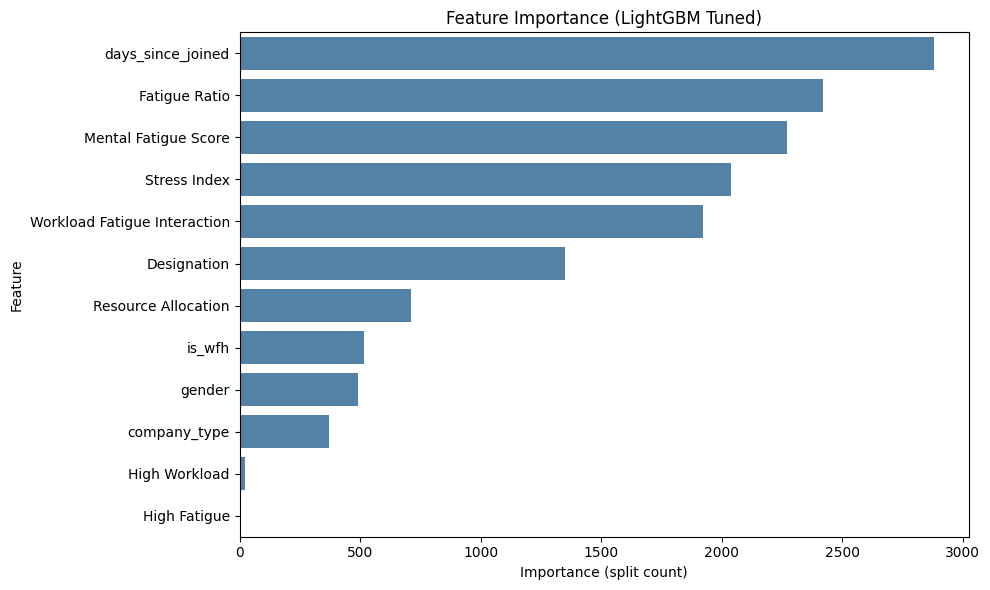

                     Feature  Importance
           days_since_joined        2880
               Fatigue Ratio        2419
        Mental Fatigue Score        2272
                Stress Index        2037
Workload Fatigue Interaction        1923
                 Designation        1351
         Resource Allocation         713
                      is_wfh         515
                      gender         492
                company_type         370
               High Workload          22
                High Fatigue           6


In [15]:
#Feature Importance 
importance_df = pd.DataFrame({
    "Feature":    feature_cols,
    "Importance": lgb_tuned.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Importance", y="Feature", color="steelblue")
plt.title("Feature Importance (LightGBM Tuned)")
plt.xlabel("Importance (split count)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

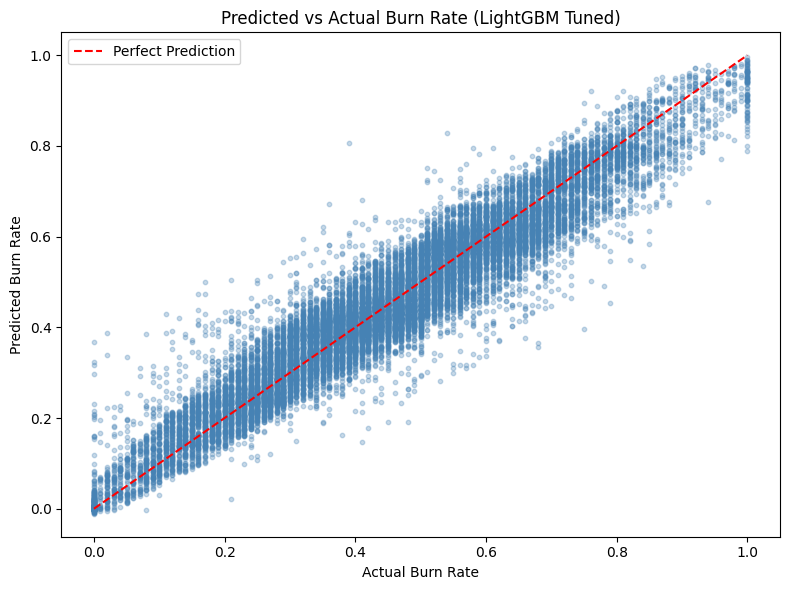

In [16]:
y_pred_tuned = lgb_tuned.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred_tuned, alpha=0.3, s=10, color="steelblue")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=1.5, label="Perfect Prediction")
plt.xlabel("Actual Burn Rate")
plt.ylabel("Predicted Burn Rate")
plt.title("Predicted vs Actual Burn Rate (LightGBM Tuned)")
plt.legend()
plt.tight_layout()
plt.show()

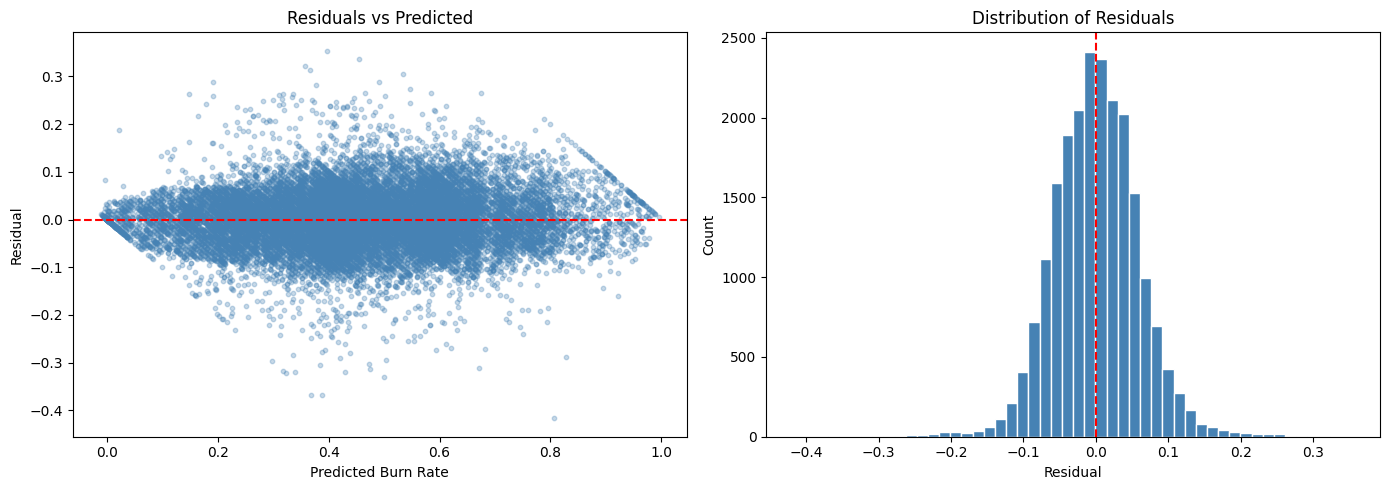

Mean Residual : 0.000000  (should be close to 0)
Std Residual  : 0.0599


In [17]:
#Residual Analysis 
residuals = y - y_pred_tuned

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_tuned, residuals, alpha=0.3, s=10, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Predicted Burn Rate")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

# Distribution of residuals
axes[1].hist(residuals, bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

print(f"Mean Residual : {residuals.mean():.6f}  (should be close to 0)")
print(f"Std Residual  : {residuals.std():.4f}")